In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy = "mean")
df["Income"]= impute.fit_transform(df[["Income"]])

               #or

# df["Income"] = df["Income"].fillna(df["Income"].mean())

### Feature Engineering


In [6]:
#Age

df["Age"] = 2026 - df["Year_Birth"]

In [7]:
#Customer Joining Date

df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date= df["Dt_Customer"].max()

df["costumer_tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days


In [8]:
df["Dt_Customer"]

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2240, dtype: datetime64[ns]

In [9]:
# Spending 

df["Total_Spending"]= df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [10]:
# Children 

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [11]:
df["Education"]

0       Graduation
1       Graduation
2       Graduation
3       Graduation
4              PhD
           ...    
2235    Graduation
2236           PhD
2237    Graduation
2238        Master
2239           PhD
Name: Education, Length: 2240, dtype: object

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,costumer_tenure_days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
#Education

df["Education"]= df["Education"].replace({

    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Masters" : "Postgraduate", "PhD" : "Postgraduate"
})

In [15]:
# Marital status

df["Marital_Status"]= df["Marital_Status"].replace({

    "Married" : "Partner", "Together" : "Partner",
    "Single" : "Alone", "Alone" : "Alone",
    "Divorced" : "Alone", "Widow" : "Alone",
    "Absurd" : "Alone", "YOLO" : "Alone"
})

In [16]:
# Droping Columns

cols = ["ID", "Year_Birth", "Kidhome", "Teenhome", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "Dt_Customer" ]

new_df = df.drop(columns= cols)

### Outliers

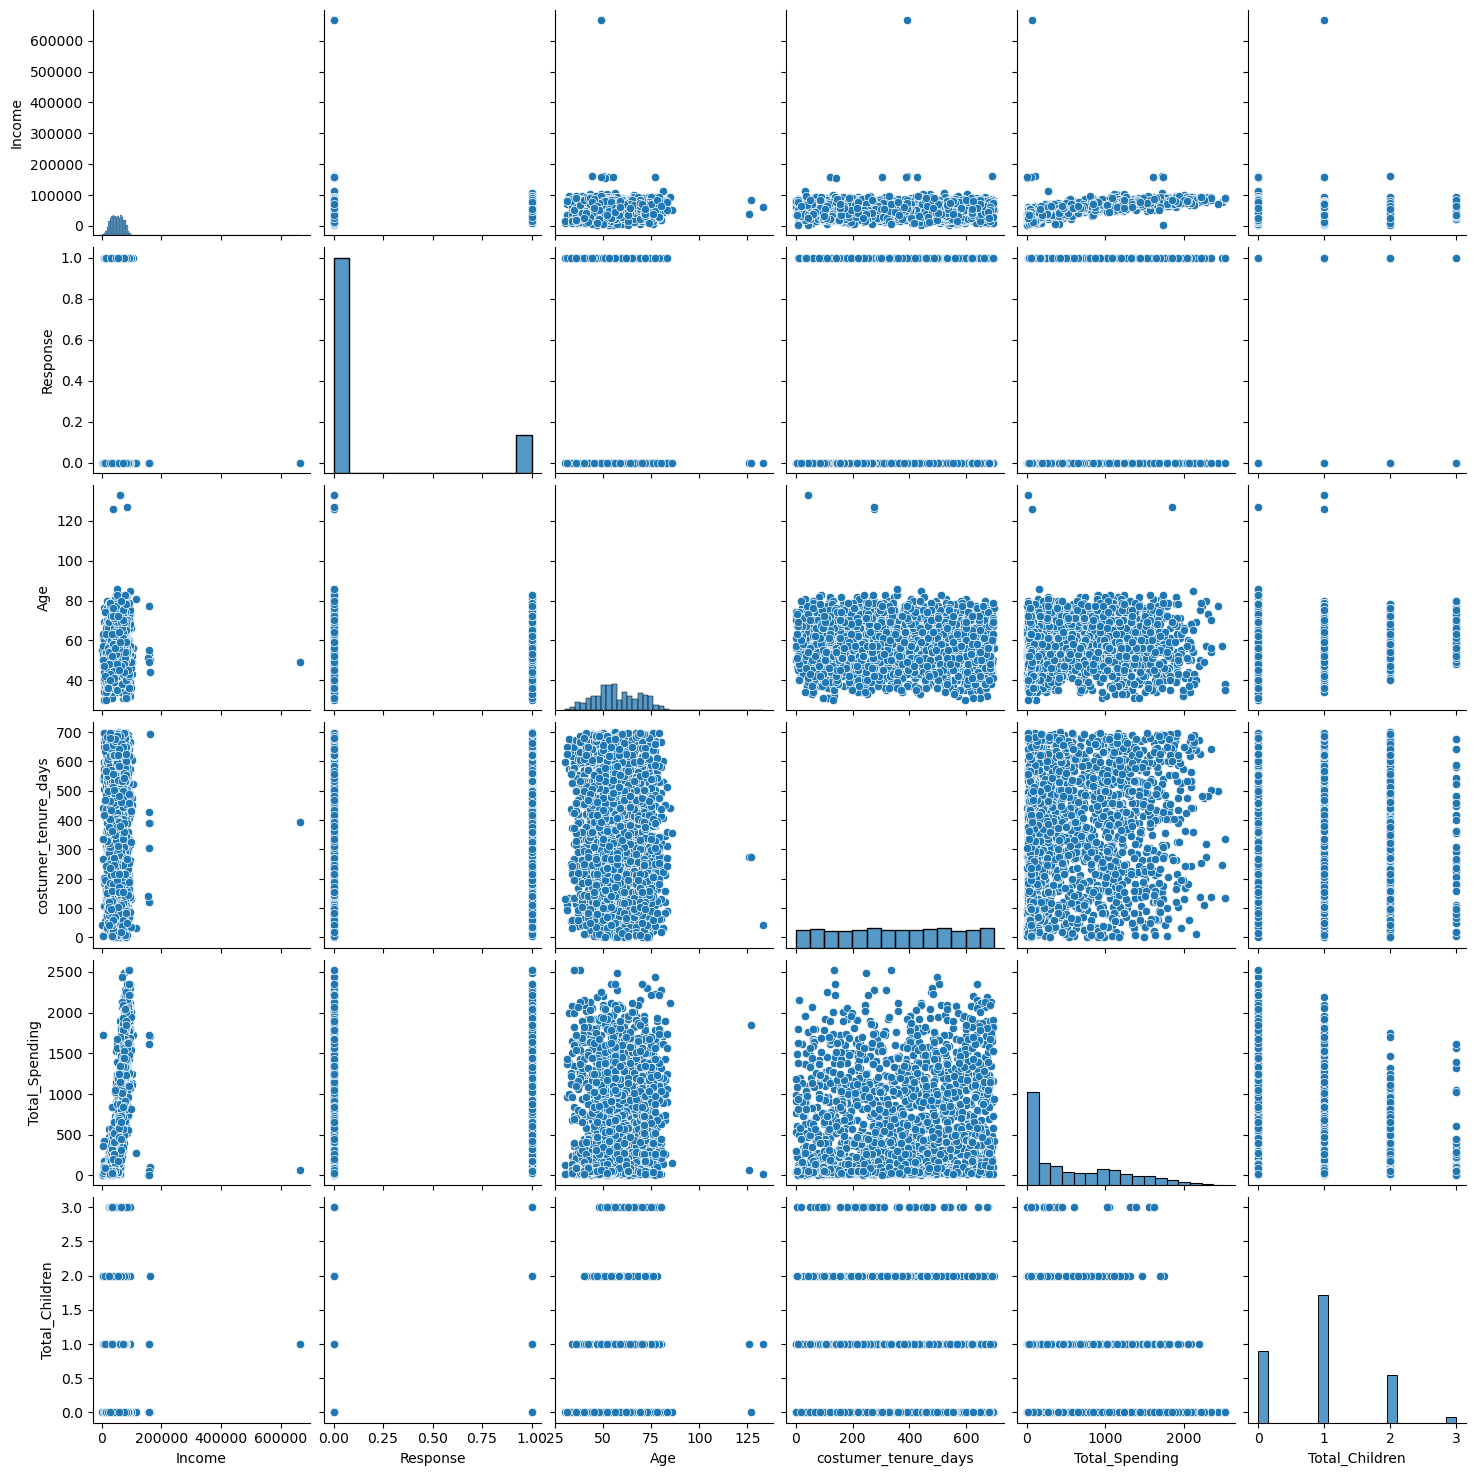

In [18]:
colms = ["Education", "Income", "Response", "Age", "costumer_tenure_days", "Total_Spending", "Total_Children"]

sns.pairplot(new_df[colms])

In [19]:
# removing outliers

print("length of dataset : ", len(new_df))

new_df = new_df[(new_df["Age"] < 90)] 
new_df = new_df[(new_df["Income"] < 600_000)]

print("length of dataset : ", len(new_df))


length of dataset :  2240
length of dataset :  2236


### Feature Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ["Education", "Marital_Status"]

enc_cols = ohe.fit_transform(new_df[cat_cols])

In [22]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index= new_df.index)

In [23]:
encoded_df = pd.concat([new_df.drop(columns= cat_cols), enc_df], axis = 1)

In [24]:
encoded_df = encoded_df.drop(columns= "Education_Master")

In [25]:
X = encoded_df

### Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler()
X_scaled = scaled.fit_transform(X)

### Visualize

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 3)
X_pca = pca.fit_transform(X_scaled)

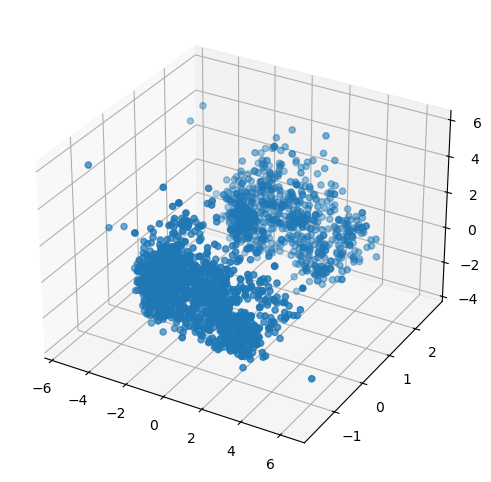

In [30]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])


### Finding K


In [32]:
# Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\anura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

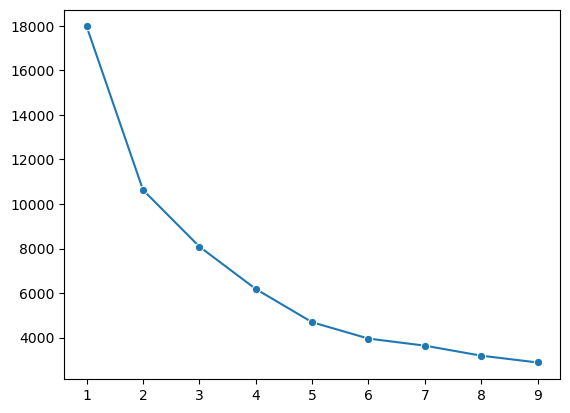

In [33]:
sns.lineplot(x=range(1, 10), y=wcss, marker= 'o')

In [34]:
knee = KneeLocator(range(1, 10), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow
optimal_k                

4

### Clustring

In [36]:
# K_Means clustring

kmeans = KMeans(n_clusters= 4, random_state= 42)
label_kmeans= kmeans.fit_predict(X_pca)

C:\Users\anura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


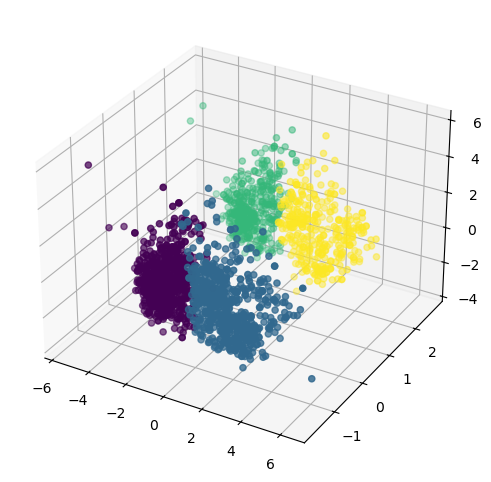

In [37]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c= label_kmeans)


In [38]:
# Agglomerative Clustring

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters= 4, linkage= "ward")
label_agg = agg.fit_predict(X_pca)

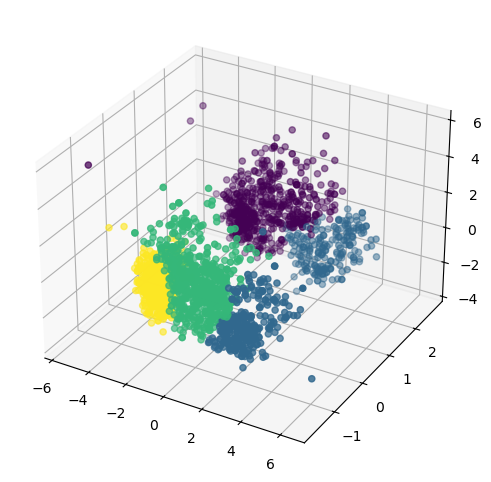

In [39]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c= label_agg)

### Characterization of Clusters

In [41]:
new_df["labels"] = label_kmeans

<Axes: xlabel='labels', ylabel='count'>

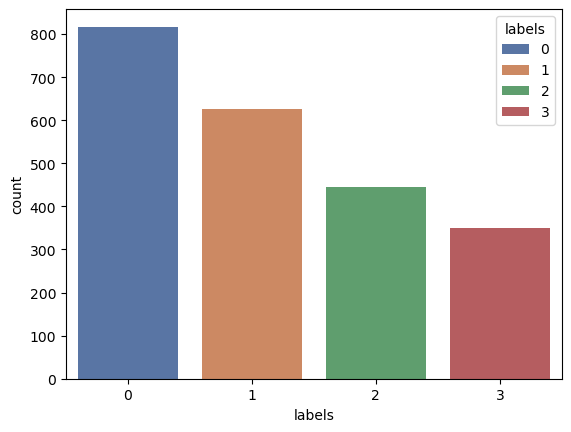

In [42]:
sns.countplot(x= new_df["labels"], palette= "deep", hue=new_df["labels"] )